# Ammonia as a Refrigerant

This notebook compares ammonia (R-717), propane (R-290), and CO₂ (R-744) as
refrigerants for industrial cooling applications using NeqSim.

We simulate and compare:
1. **Vapor-compression refrigeration cycles** for each refrigerant
2. **Coefficient of Performance (COP)** comparison
3. **Effect of evaporator temperature** on COP and compressor discharge temperature
4. **Pressure-enthalpy (P-h) diagrams**

## Background

| Property | NH₃ (R-717) | C₃H₈ (R-290) | CO₂ (R-744) |
|----------|-------------|---------------|-------------|
| Boiling point (°C) | -33.3 | -42.1 | -78.5 (sublimes) |
| Critical temp (°C) | 132.4 | 96.7 | 31.0 |
| Critical pressure (bara) | 113.5 | 42.5 | 73.8 |
| ODP | 0 | 0 | 0 |
| GWP (100yr) | 0 | 3 | 1 |
| Toxicity | Yes (B2L) | No (A3) | No (A1) |

In [1]:
# Setup NeqSim
import subprocess, sys
try:
    from neqsim import jneqsim
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'neqsim'])
    from neqsim import jneqsim

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
Stream = jneqsim.process.equipment.stream.Stream
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Separator = jneqsim.process.equipment.separator.Separator
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations

print('NeqSim loaded successfully')

NeqSim loaded successfully


## 1. Refrigeration Cycle Simulation

Simulate a simple single-stage vapor-compression cycle for each refrigerant:
- **Evaporator** at -10°C (cold side)
- **Condenser** at 35°C (warm side / ambient rejection)
- **Compressor** with 75% isentropic efficiency
- **Expansion valve** (isenthalpic)

The cycle COP is calculated as: COP = Q_evaporator / W_compressor

In [2]:
def simulate_refrigeration_cycle(refrigerant_name, evap_temp_C, cond_temp_C, eos_type='SRK'):
    """
    Simulate a single-stage vapor-compression refrigeration cycle.
    Returns: dict with COP, power, duty, temperatures, pressures
    """
    # Step 1: Find saturation pressures at evaporator and condenser temperatures
    # Evaporator pressure (bubble point)
    if eos_type == 'CPA':
        fluid_evap = SystemSrkCPAstatoil(273.15 + evap_temp_C, 5.0)
    else:
        fluid_evap = SystemSrkEos(273.15 + evap_temp_C, 5.0)
    fluid_evap.addComponent(refrigerant_name, 1.0)
    fluid_evap.setMixingRule('classic')
    ops_evap = ThermodynamicOperations(fluid_evap)
    ops_evap.bubblePointPressureFlash(False)
    P_evap = fluid_evap.getPressure('bara')

    # Condenser pressure
    if eos_type == 'CPA':
        fluid_cond = SystemSrkCPAstatoil(273.15 + cond_temp_C, 10.0)
    else:
        fluid_cond = SystemSrkEos(273.15 + cond_temp_C, 10.0)
    fluid_cond.addComponent(refrigerant_name, 1.0)
    fluid_cond.setMixingRule('classic')
    ops_cond = ThermodynamicOperations(fluid_cond)
    ops_cond.bubblePointPressureFlash(False)
    P_cond = fluid_cond.getPressure('bara')

    # Step 2: Build process
    # Compressor suction: saturated vapor at evaporator conditions
    if eos_type == 'CPA':
        suction_fluid = SystemSrkCPAstatoil(273.15 + evap_temp_C, P_evap)
    else:
        suction_fluid = SystemSrkEos(273.15 + evap_temp_C, P_evap)
    suction_fluid.addComponent(refrigerant_name, 1.0)
    suction_fluid.setMixingRule('classic')

    suction_stream = Stream('Suction', suction_fluid)
    suction_stream.setFlowRate(10000.0, 'kg/hr')
    suction_stream.setTemperature(evap_temp_C + 5.0, 'C')  # 5°C superheat
    suction_stream.setPressure(P_evap, 'bara')

    process = ProcessSystem()
    process.add(suction_stream)

    # Compressor
    comp = Compressor('Compressor', suction_stream)
    comp.setOutletPressure(P_cond)
    comp.setIsentropicEfficiency(0.75)
    process.add(comp)

    # Condenser (cool to condensing temperature + subcool)
    condenser = Cooler('Condenser', comp.getOutletStream())
    condenser.setOutTemperature(273.15 + cond_temp_C - 2.0)  # 2°C subcooling
    process.add(condenser)

    # Expansion valve
    exp_valve = ThrottlingValve('Exp Valve', condenser.getOutletStream())
    exp_valve.setOutletPressure(P_evap)
    process.add(exp_valve)

    # Evaporator (heater to superheat)
    evaporator = Heater('Evaporator', exp_valve.getOutletStream())
    evaporator.setOutTemperature(273.15 + evap_temp_C + 5.0)
    process.add(evaporator)

    process.run()

    # Calculate COP
    W_comp = abs(comp.getPower('kW'))
    Q_evap = abs(evaporator.getDuty()) / 1000.0  # W to kW
    Q_cond = abs(condenser.getDuty()) / 1000.0
    COP = Q_evap / W_comp if W_comp > 0 else 0

    T_discharge = comp.getOutletStream().getTemperature() - 273.15

    return {
        'refrigerant': refrigerant_name,
        'P_evap_bara': P_evap,
        'P_cond_bara': P_cond,
        'pressure_ratio': P_cond / P_evap,
        'T_discharge_C': T_discharge,
        'W_comp_kW': W_comp,
        'Q_evap_kW': Q_evap,
        'Q_cond_kW': Q_cond,
        'COP': COP
    }

# Simulate for each refrigerant
evap_T = -10.0  # °C
cond_T = 35.0   # °C

results = []
results.append(simulate_refrigeration_cycle('ammonia', evap_T, cond_T, 'CPA'))
results.append(simulate_refrigeration_cycle('propane', evap_T, cond_T, 'SRK'))
results.append(simulate_refrigeration_cycle('CO2', evap_T, cond_T, 'SRK'))

# Display results
df = pd.DataFrame(results)
df = df.round(2)
print('=== Refrigeration Cycle Comparison ===')
print(f'Evaporator: {evap_T}°C, Condenser: {cond_T}°C, Flow: 10,000 kg/hr')
print()
print(df[['refrigerant', 'P_evap_bara', 'P_cond_bara', 'pressure_ratio',
          'T_discharge_C', 'W_comp_kW', 'Q_evap_kW', 'COP']].to_string(index=False))

=== Refrigeration Cycle Comparison ===
Evaporator: -10.0°C, Condenser: 35.0°C, Flow: 10,000 kg/hr

refrigerant  P_evap_bara  P_cond_bara  pressure_ratio  T_discharge_C  W_comp_kW  Q_evap_kW  COP
    ammonia         0.03         0.37           12.78         164.62    1479.09    5555.29 3.76
    propane         3.46        12.33            3.57          55.76     228.02     793.88 3.48
        CO2        26.58        10.00            0.38         -39.99     134.86     161.25 1.20


## 2. COP vs Evaporator Temperature

Study how the evaporator temperature (cooling duty temperature) affects the COP
for each refrigerant.

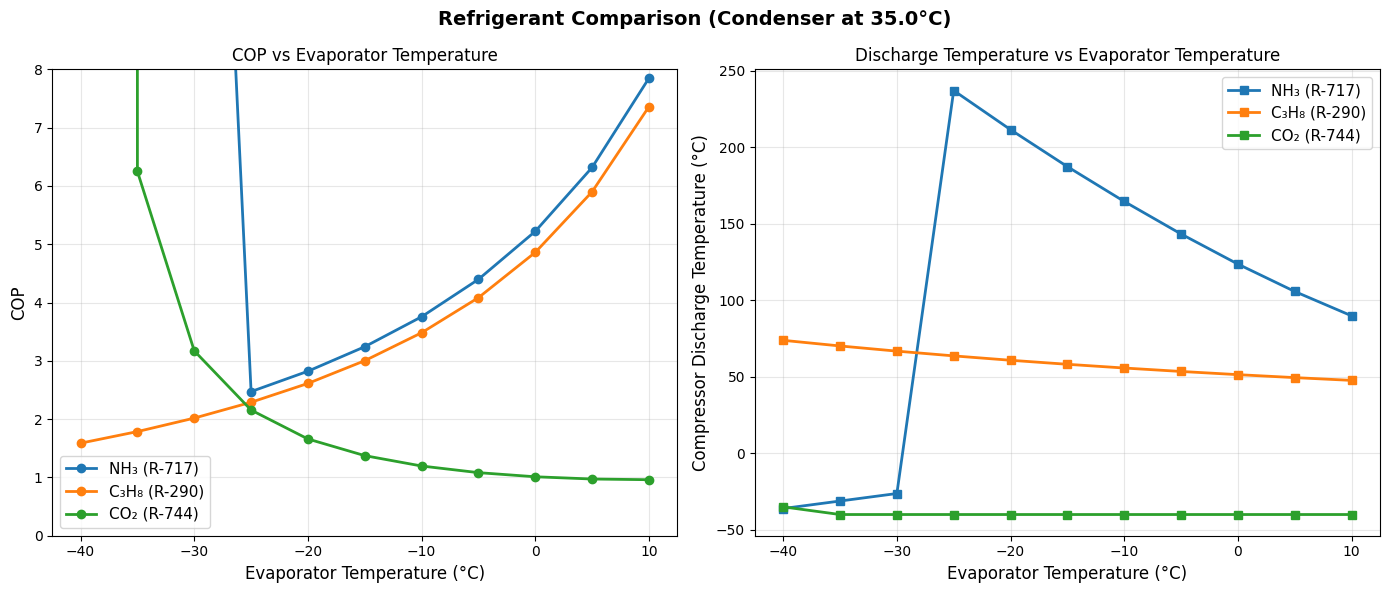

Figure saved: refrigerant_comparison.png


In [3]:
# COP sensitivity to evaporator temperature
evap_temps = np.arange(-40, 15, 5)
cond_temp = 35.0

refrigerants = [
    ('ammonia', 'CPA', 'NH₃ (R-717)', '#1f77b4'),
    ('propane', 'SRK', 'C₃H₈ (R-290)', '#ff7f0e'),
    ('CO2', 'SRK', 'CO₂ (R-744)', '#2ca02c')
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ref_name, eos, label, color in refrigerants:
    cops = []
    t_discharges = []

    for evap_t in evap_temps:
        try:
            r = simulate_refrigeration_cycle(ref_name, float(evap_t), cond_temp, eos)
            cops.append(r['COP'])
            t_discharges.append(r['T_discharge_C'])
        except Exception:
            cops.append(float('nan'))
            t_discharges.append(float('nan'))

    ax1.plot(evap_temps, cops, 'o-', color=color, label=label, linewidth=2, markersize=6)
    ax2.plot(evap_temps, t_discharges, 's-', color=color, label=label, linewidth=2, markersize=6)

ax1.set_xlabel('Evaporator Temperature (°C)', fontsize=12)
ax1.set_ylabel('COP', fontsize=12)
ax1.set_title('COP vs Evaporator Temperature')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 8)

ax2.set_xlabel('Evaporator Temperature (°C)', fontsize=12)
ax2.set_ylabel('Compressor Discharge Temperature (°C)', fontsize=12)
ax2.set_title('Discharge Temperature vs Evaporator Temperature')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.suptitle(f'Refrigerant Comparison (Condenser at {cond_temp}°C)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('refrigerant_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: refrigerant_comparison.png')

## 3. Pressure-Enthalpy Diagram

Generate a P-h diagram for ammonia showing the saturation curve and key cycle points.

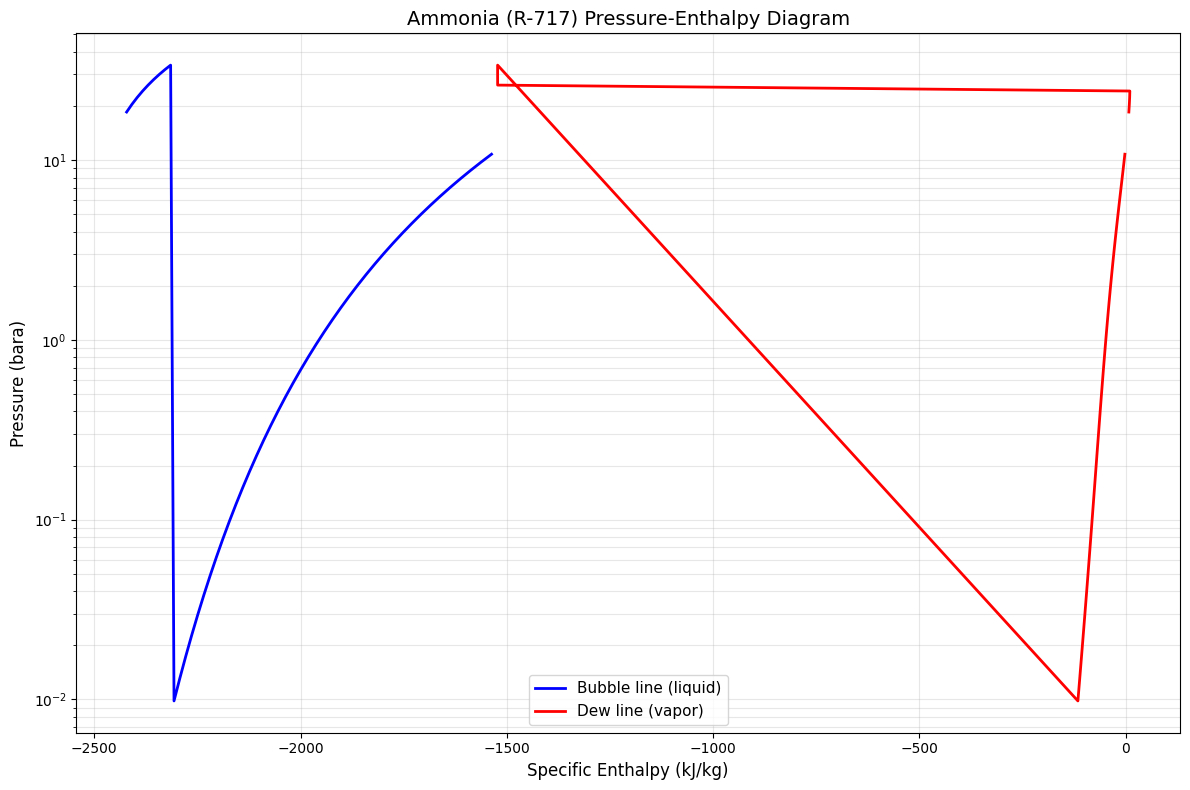

Figure saved: ammonia_ph_diagram.png


In [4]:
# Generate P-h diagram for ammonia
temps_sat = np.linspace(-60, 130, 50)

p_bubble = []
h_bubble = []
h_dew = []

for t in temps_sat:
    try:
        # Bubble point (liquid)
        f_liq = SystemSrkCPAstatoil(273.15 + float(t), 5.0)
        f_liq.addComponent('ammonia', 1.0)
        f_liq.setMixingRule('classic')
        ops = ThermodynamicOperations(f_liq)
        ops.bubblePointPressureFlash(False)
        f_liq.initProperties()

        p_sat = f_liq.getPressure('bara')
        p_bubble.append(p_sat)
        h_bubble.append(f_liq.getEnthalpy('kJ/kg'))

        # Dew point (vapor) at same pressure
        f_vap = SystemSrkCPAstatoil(273.15 + float(t), p_sat)
        f_vap.addComponent('ammonia', 1.0)
        f_vap.setMixingRule('classic')
        ops_v = ThermodynamicOperations(f_vap)
        ops_v.dewPointTemperatureFlash()
        f_vap.initProperties()
        h_dew.append(f_vap.getEnthalpy('kJ/kg'))
    except Exception:
        p_bubble.append(float('nan'))
        h_bubble.append(float('nan'))
        h_dew.append(float('nan'))

fig, ax = plt.subplots(figsize=(12, 8))

# Saturation curve
ax.semilogy(h_bubble, p_bubble, 'b-', linewidth=2, label='Bubble line (liquid)')
ax.semilogy(h_dew, p_bubble, 'r-', linewidth=2, label='Dew line (vapor)')

ax.set_xlabel('Specific Enthalpy (kJ/kg)', fontsize=12)
ax.set_ylabel('Pressure (bara)', fontsize=12)
ax.set_title('Ammonia (R-717) Pressure-Enthalpy Diagram', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('ammonia_ph_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: ammonia_ph_diagram.png')

## Summary

Key findings from the refrigerant comparison:

- **Ammonia (R-717)** generally achieves the highest COP due to its high latent heat of vaporization
- **Propane (R-290)** is a good alternative with moderate COP, but is flammable (A3)
- **CO₂ (R-744)** operates at much higher pressures and has lower COP in subcritical cycles,
  but is non-toxic and non-flammable
- Ammonia's high discharge temperature is a disadvantage requiring careful design
- At lower evaporator temperatures, the COP advantage of ammonia becomes more pronounced

### Applications
- **Ammonia:** Industrial refrigeration, cold storage, ice rinks, food processing
- **Propane:** Heat pumps, commercial refrigeration, compact systems
- **CO₂:** Supermarket refrigeration (transcritical), heat pumps, mobile A/C